In [3]:
import matplotlib
%matplotlib inline

HPC Coordinate: 300.0 arcsec, -300.0 arcsec
HGC Coordinate: 336.27542140991653 deg, -17.16419564531887 deg
new HGC Coordinate: 336.27542140991653 deg, -17.16419564531887 deg
new HPC Coordinate: 660.9825708421006 arcsec, -293.9092631133358 arcsec


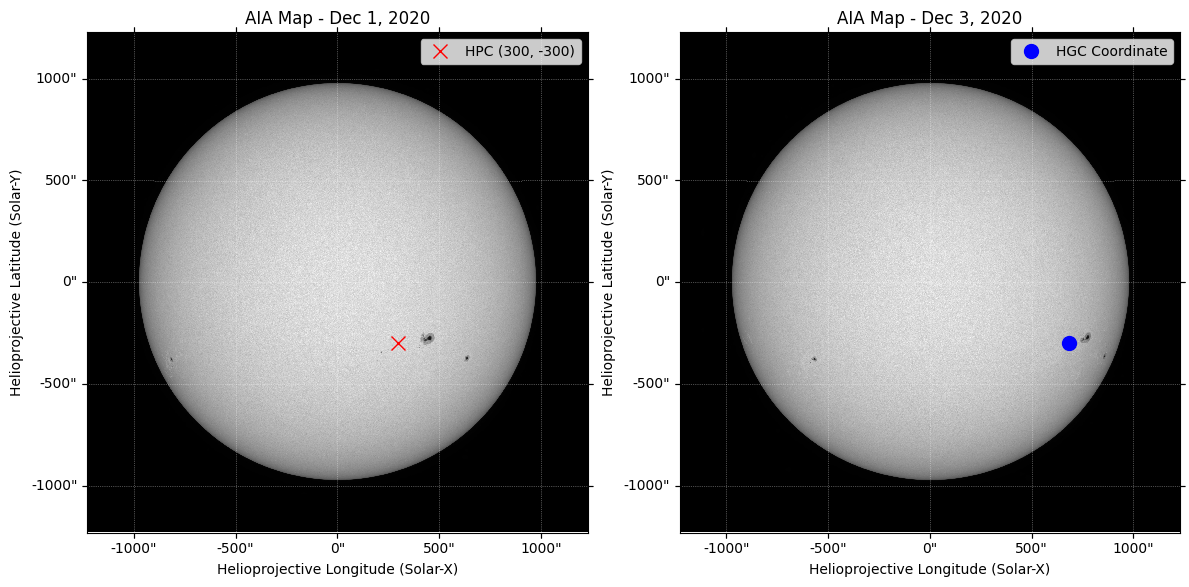

In [9]:
import os
import urllib.request
import warnings
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from sunpy.map import Map
from sunpy.physics.differential_rotation import solar_rotate_coordinate
from sunpy.coordinates import get_earth, HeliographicStonyhurst, HeliographicCarrington, Helioprojective

warnings.filterwarnings("ignore", category=UserWarning, module="sunpy")

testfield = '/Users/fisher/myworkspace/testfield/'
if not os.path.exists(testfield):
    os.makedirs(testfield)
os.chdir(testfield)

# Define data source and key
aiaDataSource = {
    "_HMIcont": 18,  # HMI Continuum
}
key = "_HMIcont"

# Function to download and load AIA map
def get_aia_map(date_str, key):
    sourceid = aiaDataSource[key]
    sdourl = f"https://api.helioviewer.org/v2/getJP2Image/?date={date_str}T20:00:00Z&sourceId={sourceid}"
    sdofile = f"{date_str}{key}.jp2"

    if not os.path.exists(sdofile):
        urllib.request.urlretrieve(sdourl, sdofile)

    return Map(sdofile)

# Load maps for December 1 and December 3, 2020
amap_20201201 = get_aia_map("2020-12-01", key)
amap_20201203 = get_aia_map("2020-12-03", key)

# Define the HPC coordinate (300, -300) arcsec

obstime1 = Time("2020-12-01T20:00:00", scale="utc")
observer1 = get_earth(obstime1)
hpc_coord = SkyCoord(300 * u.arcsec, -300 * u.arcsec, obstime=obstime1, observer=observer1, rsun=696 * u.Mm, frame='helioprojective')
print(f"HPC Coordinate: {hpc_coord.Tx}, {hpc_coord.Ty}")
# Convert to HGC (Carrington) coordinates
obstime2 = Time("2020-12-03T20:00:00", scale="utc")
observer2 = get_earth(obstime2)
hgc_coord = hpc_coord.transform_to(HeliographicCarrington(obstime=obstime1, observer=observer1))
print(f"HGC Coordinate: {hgc_coord.lon}, {hgc_coord.lat}")
hgc_coord_new = SkyCoord(hgc_coord.lon, hgc_coord.lat, obstime=obstime2, observer=observer2, radius=696 * u.Mm, frame='heliographic_carrington')
print(f"new HGC Coordinate: {hgc_coord_new.lon}, {hgc_coord_new.lat}")
hpc_coord_new = hgc_coord_new.transform_to(Helioprojective(obstime=obstime2, observer=observer2, rsun=696 * u.Mm))
print(f"new HPC Coordinate: {hpc_coord_new.Tx}, {hpc_coord_new.Ty}")

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": amap_20201201.wcs})

# Panel 1: Plot AIA map for 2020-12-01 and mark HPC coordinate
amap_20201201.plot(axes=axes[0])
axes[0].plot_coord(hpc_coord, 'rx', markersize=10, label="HPC (300, -300)")
axes[0].set_title("AIA Map - Dec 1, 2020")
axes[0].legend()

# Panel 2: Plot AIA map for 2020-12-03 and mark HGC coordinate
amap_20201203.plot(axes=axes[1])
axes[1].plot_coord(hpc_coord_new, 'bo', markersize=10, label="HGC Coordinate")
axes[1].set_title("AIA Map - Dec 3, 2020")
axes[1].legend()

plt.tight_layout()
plt.show()
